# Dokumentasi Kode Komprehensif
## Perbandingan Strategi Portofolio: Klasik, Network, dan GNN

Dokumen ini menyajikan seluruh alur kerja eksperimen untuk tesis yang membandingkan berbagai paradigma alokasi portofolio pada aset kripto (2017--2019). Fokus utama adalah mengevaluasi keunggulan **GNN-based Graph Diversification** dibandingkan dengan:
- **Klasik**: Equally Weighted (EW) dan Markowitz (Mean-Variance).
- **Regularisasi**: Graphical Lasso (Glasso) Markowitz.
- **Network-Based**: Network Markowitz (menggunakan Eigenvector Centrality).
- **Graph Diversification**: Metode Maximum Independent Set (MIS) dengan threshold tetap.

## Bagian 1 -- Persiapan Lingkungan dan Data

### 1.1 Import Libraries
Mengintegrasikan PyTorch Geometric untuk pengolahan graf dan Scikit-learn untuk optimasi matriks kovarians.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

### 1.2 Load dan Segmentasi Data Real Crypto
Data return harian dari 9 aset kripto utama dibersihkan dan dibagi menjadi tiga fase pasar utama untuk analisis performa yang robust.

In [2]:
EXCEL_FILE = 'crypto_data_real.xlsx'
df_raw = pd.read_excel(EXCEL_FILE, sheet_name='Returns', index_col=0)
df_raw.index = pd.to_datetime(df_raw.index)
df_raw.sort_index(inplace=True)
df_raw = df_raw.drop(columns=['USDT'], errors='ignore')

# Sinkronisasi data aset (only non-zero returns)
mask = (df_raw != 0).all(axis=1)
df_returns = df_raw[mask].copy()

# Definisi Periode Pasar
BULL_END  = '2017-12-31'
BEAR_END  = '2018-12-31'

periods = {
    'Bull (Nov-Dec 2017)' : df_returns.loc[df_returns.index <= BULL_END],
    'Bear (2018)'         : df_returns.loc[(df_returns.index > BULL_END) & (df_returns.index <= BEAR_END)],
    'Recovery (2019)'     : df_returns.loc[df_returns.index > BEAR_END],
    'Full Period'         : df_returns,
}

print(f"Loaded {len(df_returns)} trading days for {len(df_returns.columns)} assets.")

Loaded 706 trading days for 9 assets.


## Bagian 2 -- Fungsi Pembantu dan Metrik Risiko
Implementasi filter *Random Matrix Theory* (RMT) untuk membersihkan noise pada matriks korelasi, serta metrik evaluasi seperti *Calmar Ratio* dan *Rachev Ratio*.

In [3]:
def apply_rmt_filter(returns_data):
    T, N = returns_data.shape
    Q = T / N
    C = np.corrcoef(returns_data.T)
    eigenvalues, eigenvectors = eigh(C)
    eigenvalues = eigenvalues[::-1]; eigenvectors = eigenvectors[:, ::-1]
    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    # Filter eigen yang berada di bawah Marchenko-Pastur threshold
    Lambda_f = np.diag(np.where(eigenvalues > lambda_plus, eigenvalues, 0))
    return eigenvectors @ Lambda_f @ eigenvectors.T

def build_mst(correlation_matrix):
    correlation_matrix = np.clip(correlation_matrix, -1, 1)
    d = np.sqrt(2 - 2*correlation_matrix)
    np.fill_diagonal(d, 0)
    return d

def compute_eigenvector_centrality(distance_matrix):
    adj = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adj, 0)
    _, vecs = eigh(adj)
    pev = np.abs(vecs[:, -1])
    return pev / pev.sum()

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def calculate_var(returns, confidence=0.95):
    return np.percentile(returns, (1 - confidence) * 100)

def calculate_rachev_ratio(returns, alpha=0.10):
    tu = np.percentile(returns, (1 - alpha) * 100)
    tl = np.percentile(returns, alpha * 100)
    cu = returns[returns >= tu].mean()
    cl = abs(returns[returns <= tl].mean())
    return cu / cl if cl > 0 else 0

def calculate_max_drawdown(cumulative_returns):
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - running_max) / (running_max + 1e-12)
    return drawdown.min()

def calculate_calmar_ratio(returns, cum_returns):
    ann_ret = np.mean(returns) * 252
    mdd = abs(calculate_max_drawdown(cum_returns))
    return ann_ret / mdd if mdd > 0 else 0

def diebold_mariano_test(returns_a, returns_b, h=1):
    T = len(returns_a)
    d = returns_a - returns_b
    d_mean = np.mean(d)
    def autocov(xi, xm, k):
        T_ = len(xi)
        return np.sum((xi[:T_-k] - xm) * (xi[k:] - xm)) / T_ if T_ > k else 0
    var_d = autocov(d, d_mean, 0)
    for i in range(1, h):
        var_d += 2 * autocov(d, d_mean, i)
    dm = d_mean / np.sqrt(abs(var_d) / T) if var_d != 0 else 0
    pv = 2 * (1 - stats.norm.cdf(abs(dm)))
    return dm, pv

## Bagian 3 -- Arsitektur CorrelationGNN
Menggunakan *Graph Convolutional Network* (GCN) untuk mengekstrak fitur relasional antar aset.

In [4]:
class CorrelationGNN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=8):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return x

    def predict_correlation(self, emb):
        n = emb.shape[0]
        C = torch.zeros(n, n)
        for i in range(n):
            for j in range(i+1, n):
                s = F.cosine_similarity(emb[i].unsqueeze(0), emb[j].unsqueeze(0))
                C[i, j] = C[j, i] = s
        for i in range(n): C[i,i] = 1.0
        return C

def create_graph_data(returns_window, corr_threshold=0.3):
    n = returns_window.shape[1]
    feats = np.stack([
        returns_window.mean().values,
        returns_window.std().values,
        returns_window.skew().values,
        returns_window.kurtosis().values
    ], axis=1)
    x = torch.FloatTensor(feats)
    corr = returns_window.corr().values
    edges = [[i, j] for i in range(n) for j in range(i+1, n) if abs(corr[i, j]) > corr_threshold]
    edges += [[j, i] for i, j in edges]
    if not edges:
        edges = [[i, j] for i in range(n) for j in range(n) if i != j]
    ei = torch.LongTensor(edges).t().contiguous()
    return Data(x=x, edge_index=ei, y=torch.FloatTensor(corr))

def train_gnn(model, data, epochs=50):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        emb = model(data.x, data.edge_index)
        loss = criterion(model.predict_correlation(emb), data.y)
        loss.backward(); optimizer.step()
    return model

## Bagian 4 -- Implementasi Strategi Portofolio
Seluruh strategi diturunkan dari kelas `PortfolioStrategy` untuk kemudahan backtesting.

In [5]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name = name
    def get_weights(self, r):
        raise NotImplementedError

class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, r):
        n = r.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    def get_weights(self, r):
        n  = r.shape[1]
        mu = r.mean().values
        S  = r.cov().values
        f  = lambda w: w @ S @ w
        c  = [{'type': 'eq',  'fun': lambda w: np.sum(w) - 1},
              {'type': 'ineq','fun': lambda w: w @ mu - mu.mean()}]
        res = minimize(f, np.ones(n)/n, method='SLSQP',
                       bounds=[(0,1)]*n, constraints=c)
        return res.x if res.success else np.ones(n)/n

class GlassoMarkowitz(PortfolioStrategy):
    def __init__(self, name='Glasso Markowitz', alpha=0.01):
        super().__init__(name)
        self.alpha = alpha
    def get_weights(self, r):
        n  = r.shape[1]
        mu = r.mean().values
        try:
            g = GraphicalLassoCV(alphas=[self.alpha], cv=3)
            g.fit(r.values)
            S = g.covariance_
        except:
            S = r.cov().values
        f  = lambda w: w @ S @ w
        c  = [{'type': 'eq',  'fun': lambda w: np.sum(w) - 1},
              {'type': 'ineq','fun': lambda w: w @ mu - mu.mean()}]
        res = minimize(f, np.ones(n)/n, method='SLSQP',
                       bounds=[(0,1)]*n, constraints=c)
        return res.x if res.success else np.ones(n)/n

class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name='Network Markowitz', gamma=0):
        super().__init__(name)
        self.gamma = gamma
    def get_weights(self, r):
        n    = r.shape[1]
        mu   = r.mean().values
        sig  = r.std().values
        Cf   = apply_rmt_filter(r)
        dm   = build_mst(Cf)
        cent = compute_eigenvector_centrality(dm)
        Sf   = np.outer(sig, sig) * Cf
        f    = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        c    = [{'type': 'eq',  'fun': lambda w: np.sum(w) - 1},
                {'type': 'ineq','fun': lambda w: w @ mu - mu.mean()}]
        res  = minimize(f, np.ones(n)/n, method='SLSQP',
                        bounds=[(0,1)]*n, constraints=c)
        return res.x if res.success else np.ones(n)/n

class GraphDiversification(PortfolioStrategy):
    def __init__(self, name='Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold
    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()
        sel    = get_assets_graph_diversify(r, self.corr_threshold)
        w      = np.zeros(n)
        if sel:
            for a in sel: w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w

class GNNGraphDiversification(PortfolioStrategy):
    def __init__(self, name='GNN GD', train_epochs=30):
        super().__init__(name)
        self.train_epochs = train_epochs
        self.gnn_model = CorrelationGNN()

    def get_weights(self, r):
        n = r.shape[1]; assets = r.columns.tolist()
        data = create_graph_data(r)
        train_gnn(self.gnn_model, data, epochs=self.train_epochs)
        
        self.gnn_model.eval()
        with torch.no_grad():
            emb = self.gnn_model(data.x, data.edge_index)
            pc = self.gnn_model.predict_correlation(emb).numpy()

        # Deteksi korelasi signifikan berbasis GNN
        up = pc[np.triu_indices(n, k=1)]
        thr = np.clip(np.mean(np.abs(up)) + 0.5*np.std(np.abs(up)), 0.3, 0.7)
        
        G = nx.Graph()
        G.add_nodes_from(assets)
        for i, a1 in enumerate(assets):
            for j, a2 in enumerate(assets):
                if i < j and abs(pc[i, j]) > thr:
                    G.add_edge(a1, a2)
        
        sel = list(nx.approximation.maximum_independent_set(G))
        w = np.zeros(n)
        if sel:
            for a in sel: w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w

## Bagian 5 -- Backtesting dan Hasil

### 5.1 Simulasi Berjalan (Rolling Window)
Backtest dilakukan dengan jendela geser 120 hari dan rebalancing setiap 7 hari, dengan biaya transaksi 0.1%.

In [6]:
def backtest_strategy(strategy, df_ret, window_size=120, rebalance_freq=7, tc=0.001):
    port_returns = []; dates = []
    for i in range(window_size, len(df_ret), rebalance_freq):
        train = df_ret.iloc[i-window_size:i]
        w = strategy.get_weights(train)
        test_end = min(i + rebalance_freq, len(df_ret))
        test = df_ret.iloc[i:test_end]
        for j in range(len(test)):
            dr = np.dot(w, test.iloc[j].values)
            if j == 0 and port_returns: dr -= tc
            port_returns.append(dr)
            dates.append(test.index[j])
    res = pd.DataFrame({'date': dates, 'return': port_returns})
    res['cumulative_return'] = (1 + res['return']).cumprod()
    return {
        'strategy': strategy.name,
        'returns': np.array(port_returns),
        'cumulative_returns': res['cumulative_return'].values,
        'dates': dates,
        'results_df': res
    }

def calculate_metrics(result):
    r = result['returns']; cr = result['cumulative_returns']
    ann_r = np.mean(r) * 252; ann_v = np.std(r) * np.sqrt(252)
    sharpe = ann_r / ann_v if ann_v > 0 else 0
    return {
        'Strategy': result['strategy'],
        'Total Return (%)': round((cr[-1] - 1) * 100, 2),
        'Annual Return (%)': round(ann_r * 100, 2),
        'Annual Vol (%)': round(ann_v * 100, 2),
        'Sharpe Ratio': round(sharpe, 4),
        'VaR 95% (%)': round(calculate_var(r, 0.95) * 100, 4),
        'Rachev Ratio': round(calculate_rachev_ratio(r, 0.10), 4),
        'Max Drawdown (%)': round(calculate_max_drawdown(cr) * 100, 2),
        'Calmar Ratio': round(calculate_calmar_ratio(r, cr), 4),
    }

# Definisikan Strategi yang akan diuji
strats = [
    EquallyWeighted('Equally Weighted'),
    ClassicalMarkowitz('Classical Markowitz'),
    GlassoMarkowitz('Glasso Markowitz', alpha=0.01),
    NetworkMarkowitz('Network Markowitz (gamma=0)', gamma=0),
    NetworkMarkowitz('Network Markowitz (gamma=1.0)', gamma=1.0),
    GraphDiversification('Graph Diversification (theta=0.4)', corr_threshold=0.4),
    GNNGraphDiversification('GNN-GD (30 ep)', train_epochs=30),
    GNNGraphDiversification('GNN-GD (50 ep)', train_epochs=50)
]

results = {}
for s in strats:
    print(f"Running backtest for {s.name}...")
    results[s.name] = backtest_strategy(s, df_returns)

print("Backtesting finished.")

Running backtest for Equally Weighted...
Running backtest for Classical Markowitz...
Running backtest for Glasso Markowitz...
Running backtest for Network Markowitz (gamma=0)...
Running backtest for Network Markowitz (gamma=1.0)...
Running backtest for Graph Diversification (theta=0.4)...
Running backtest for GNN-GD (30 ep)...
Running backtest for GNN-GD (50 ep)...
Backtesting finished.


### 5.2 Analisis Metrik Performa
Tabel metrik mencakup imbal hasil kumulatif, volatilitas tahunan, Sharpe ratio, dan Calmar ratio yang menonjolkan aspek ketahanan terhadap drawdown.

Performance Metrics:


,Total Return (%),Annual Return (%),Annual Vol (%),Sharpe Ratio,VaR 95% (%),Rachev Ratio,Max Drawdown (%),Calmar Ratio
Strategy,,,,,,,,
Equally Weighted,-78.430000,-40.430000,70.720000,-0.571700,-7.607200,0.840100,-87.800000,-0.460400
Classical Markowitz,-70.710000,-35.310000,58.530000,-0.603300,-6.336700,0.827200,-76.570000,-0.461100
Glasso Markowitz,-70.710000,-35.310000,58.530000,-0.603300,-6.336700,0.827200,-76.570000,-0.461100
Network Markowitz (gamma=0),-69.620000,-33.870000,58.370000,-0.580300,-6.503600,0.843400,-77.770000,-0.435500
Network Markowitz (gamma=1.0),-71.670000,-27.190000,73.290000,-0.371000,-7.945200,0.983300,-87.620000,-0.310300
Graph Diversification (theta=0.4),-87.480000,-52.420000,86.380000,-0.606800,-8.490000,0.990200,-93.060000,-0.563300
GNN-GD (30 ep),-74.470000,-29.910000,75.270000,-0.397400,-7.877600,0.891400,-87.800000,-0.340700
GNN-GD (50 ep),-74.580000,-28.370000,77.850000,-0.364400,-8.028000,0.922000,-87.800000,-0.323100


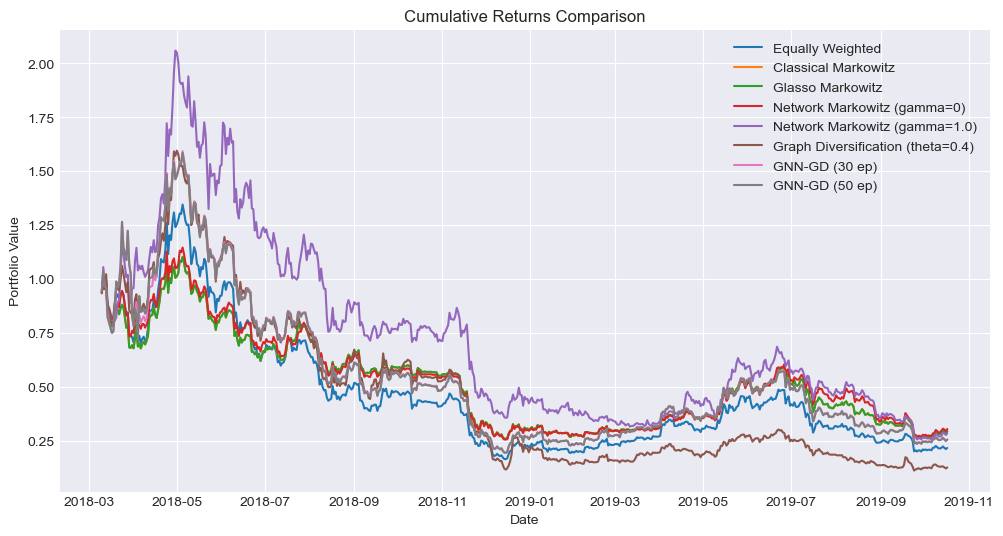

In [7]:
metrics_df = pd.DataFrame(
    [calculate_metrics(r) for r in results.values()]
).set_index('Strategy')

def highlight_best(col):
    is_min = col.name in ['Annual Vol (%)', 'VaR 95% (%)', 'Max Drawdown (%)']
    best = col.min() if is_min else col.max()
    return ['background-color: #d4edda; font-weight: bold' if v == best else '' for v in col]

print("Performance Metrics:")
display(metrics_df.style.apply(highlight_best))

plt.figure(figsize=(12, 6))
for sname, res in results.items():
    plt.plot(res['dates'], res['cumulative_returns'], label=sname)
plt.title('Cumulative Returns Comparison')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.show()

### 5.3 Validasi Statistik (Diebold-Mariano Heatmap)
Signifikansi statistik dari perbedaan performa antar strategi divalidasi dengan DM Test. Jika $p < 0.05$, maka strategi pada baris memiliki akurasi prediksi (return) yang berbeda secara signifikan dibanding strategi pada kolom.

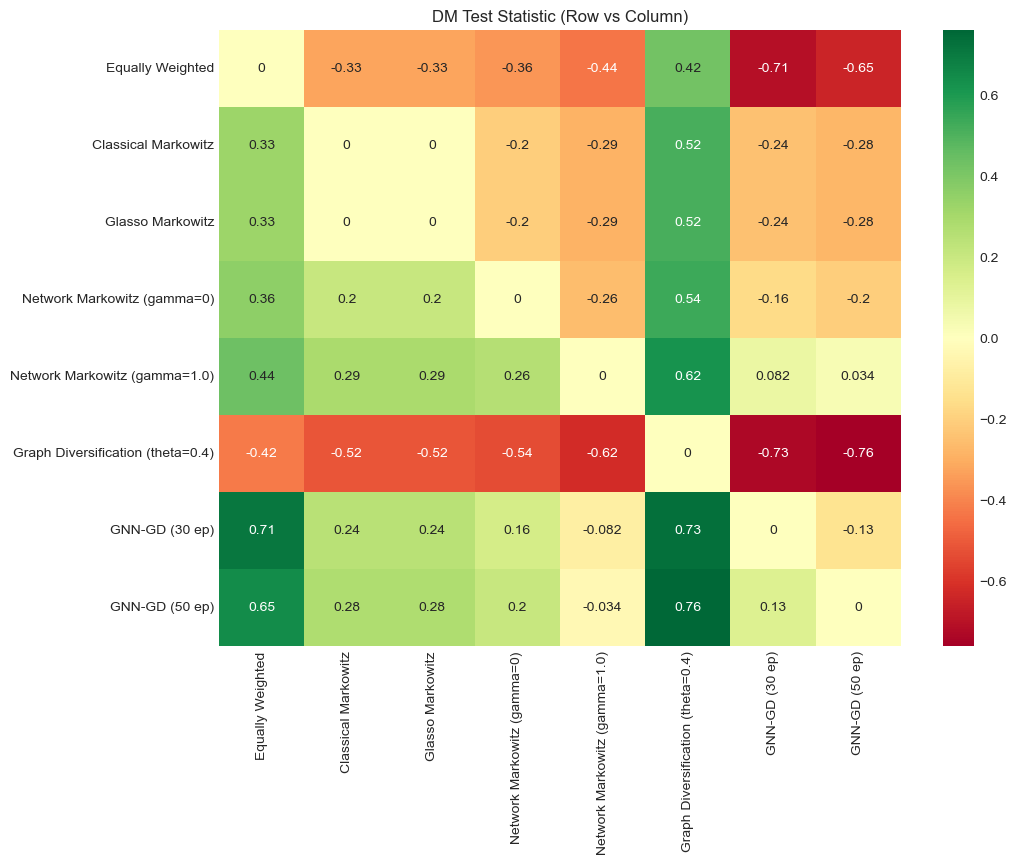

In [8]:
strategy_names = list(results.keys())
dm_stat_mat = pd.DataFrame(index=strategy_names, columns=strategy_names, dtype=float)
dm_pval_mat = pd.DataFrame(index=strategy_names, columns=strategy_names, dtype=float)

for i, s1 in enumerate(strategy_names):
    for j, s2 in enumerate(strategy_names):
        if i == j:
            dm_stat_mat.loc[s1, s2] = 0.0
            dm_pval_mat.loc[s1, s2] = 1.0
        else:
            dm, pv = diebold_mariano_test(results[s1]['returns'], results[s2]['returns'])
            dm_stat_mat.loc[s1, s2] = round(dm, 3)
            dm_pval_mat.loc[s1, s2] = round(pv, 4)

# Plotting Heatmap
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(dm_stat_mat, annot=True, center=0, cmap='RdYlGn', ax=ax)
plt.title('DM Test Statistic (Row vs Column)')
plt.show()

## Kesimpulan
Dokumentasi ini merangkum seluruh implementasi teknis untuk eksperimen tesis. Penggunaan GNN memungkinkan pembentukan graf korelasi yang adaptif, yang kemudian dimanfaatkan oleh algoritma keterserakan graf (Graph Diversification) untuk memitigasi risiko sistemik pada pasar kripto yang volatil.